# Support Vector Machines from First Principles

In this notebook, we will optimize the SVM primal objective with stochastic subgradient descent.

Check out the [blog post](https://github.com/didarulilm/ml-notebooks) where I explained how to derive the optimization problem from scratch.


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
data = pd.read_csv("../data/non_separable_data.csv")
data

,Feature 1,Feature 2,Label
0,3.764052,2.400157,0.0
1,0.729515,2.969397,0.0
2,0.826877,3.943621,0.0
3,1.586381,1.252545,0.0
4,3.922942,3.480515,0.0
...,...,...,...
295,-0.647181,0.472247,1.0
296,0.930408,-0.175316,1.0
297,-1.421920,1.997956,1.0
298,-0.856549,-1.541587,1.0


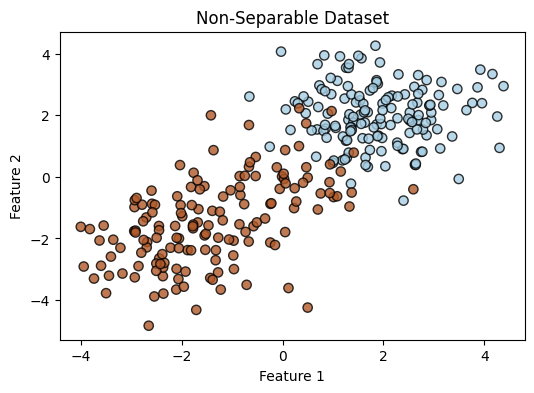

In [30]:
features = data.drop("Label", axis=1).values
labels = data["Label"].values
transformed_labels = np.where(labels == 1, 1, -1)

# Plot the dataset
plt.figure(figsize=(6, 4))
plt.scatter(
    features[:, 0],
    features[:, 1],
    c=(transformed_labels == 1).astype(int),
    cmap="Paired",
    edgecolors="k",
    s=45,
    alpha=0.8,
)
plt.title("Non-Separable Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Splitting the Dataset

Let's split the dataset into 80% training and 20% test data so we can later evaluate how well the model generalizes to unseen samples.


In [31]:
# Split the dataset into training and test set
from sklearn.model_selection import train_test_split

features_train, features_test, labels_train, labels_test = train_test_split(
    features, transformed_labels, test_size=0.2, random_state=42
)

### Cost Function, Subgradient, and Inference

Recall that our cost function $J(w,b)$ is defined as

$$
J(w,b)={\frac{\lambda}{2}||w||^2} + \frac{1}{M}\sum_{i=1}^{M} \max(0, 1 - y_i(w^Tx_i+b))
$$

where $\lambda>0$ is the regularization parameter.

The subgradient of the cost function with respect to $w$ is given by

$$
{\nabla}_{w}J(w,b) = \lambda w + \frac{1}{M}\sum_{i=1}^{M}\begin{cases}
-  y_ix_i&\quad \text{if } y_i(w^Tx_i+b) < 1\\
0 &\quad \text{otherwise}
\end{cases}
$$

and the subgradient with respect to $b$ is given by

$$
\frac{\partial}{\partial b}J(w,b)=\frac{1}{M}\sum_{i=1}^{M}\begin{cases}
-  y_i&\quad \text{if } y_i(w^Tx_i+b) < 1\\
0 &\quad \text{otherwise}
\end{cases}
$$

Given the trained parameter $w$ and $b$, the predicted label $\hat y$ for a test instance $x_{test}$ is:
$$\hat y ​=sign(w^Tx_{test}+b​)$$


In [32]:
class PrimalSVM:
    def __init__(self, lambda_param):
        """
        Initialize the SVM model.
        """
        self.lambda_param = lambda_param
        self.weights = None
        self.bias = 0.0

    def _compute_cost(self, features, labels) -> float:
        """
        Compute the scalar value of the cost function.
        """
        n_samples = features.shape[0]

        # Compute the loss term
        scores = np.dot(features, self.weights) + self.bias
        y_scores = labels * scores
        hinge_loss = np.maximum(0, 1 - y_scores)
        loss_term = np.sum(hinge_loss) / n_samples

        # Compute the overall cost
        regularizer = 0.5 * self.lambda_param * np.dot(self.weights, self.weights)
        cost = regularizer + loss_term

        return float(cost)

    def _compute_subgradient(self, features, labels) -> tuple[np.ndarray, float]:
        """
        Compute the subgradient of the cost function with respect to weights and bias.
        """
        n_samples = features.shape[0]

        scores = np.dot(features, self.weights) + self.bias
        y_scores = labels * scores
        violations = y_scores < 1

        # Compute subgradients of the regularization term
        subgrad_w = self.lambda_param * self.weights
        subgrad_b = 0.0

        # Add subgradients of the loss term
        if np.any(violations):
            subgrad_w -= np.dot(features[violations].T, labels[violations]) / n_samples
            subgrad_b -= np.sum(labels[violations]) / n_samples

        return subgrad_w, subgrad_b

    def fit(self, features, labels, epochs=1000, learning_rate=0.01, batch_size=1, tol=1e-3):
        """
        Train the model with stochastic subgradient descent with support for mini-batches.
        """
        # Initialize weight vectors to zeros
        n_samples, n_features = features.shape
        self.weights = np.zeros(n_features, dtype=float)

        rng = np.random.default_rng(seed=42)
        prev_cost = None

        # Each epoch is one full pass over the dataset
        for epoch in range(epochs):
            # Shuffle once per epoch
            indices = rng.permutation(n_samples)
            features, labels = features[indices], labels[indices]

            # Iterate over mini-batches
            for idx in range(0, n_samples, batch_size):
                features_batch = features[idx : idx + batch_size]
                labels_batch = labels[idx : idx + batch_size]

                subgrad_w, subgrad_b = self._compute_subgradient(
                    features_batch, labels_batch
                )
                self.weights -= learning_rate * subgrad_w
                self.bias -= learning_rate * subgrad_b

            curr_cost = self._compute_cost(features, labels)
            print(f"Epoch [{epoch+1}/{epochs}], Cost: {curr_cost}")

            if prev_cost is not None and abs(prev_cost - curr_cost) < tol:
                print(f"Converged at epoch {epoch + 1}")
                break
            prev_cost = curr_cost

        return self

    def predict(self, features):
        """
        Return predicted class labels for new test instance.
        """
        if self.weights is None:
            raise ValueError("Model not trained: call fit() to set weights first.")
        scores = np.dot(features, self.weights) + self.bias
        return np.sign(scores)

### Training and Evaluation

First, let's train a new model and then evaluate its performance on a separate test dataset not seen during training.


In [33]:
# Train a new SVM model
lambda_param = 0.01
svm = PrimalSVM(lambda_param)
svm.fit(features_train, labels_train, epochs=10, learning_rate=0.0001)

Epoch [1/10], Cost: 0.8738941269162187
Epoch [2/10], Cost: 0.7478487449651788
Epoch [3/10], Cost: 0.6218638326374154
Epoch [4/10], Cost: 0.5030410368231233
Epoch [5/10], Cost: 0.41162257511353656
Epoch [6/10], Cost: 0.35153879096857416
Epoch [7/10], Cost: 0.3164984898001342
Epoch [8/10], Cost: 0.2932963288006716
Epoch [9/10], Cost: 0.27572861379992947
Epoch [10/10], Cost: 0.2627185958376673


In [34]:
# Predict labels for unseen test instances and evaluate the model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

labels_pred = svm.predict(features_test)

accuracy = accuracy_score(labels_test, labels_pred)
precision = precision_score(labels_test, labels_pred)
recall = recall_score(labels_test, labels_pred)
f1 = f1_score(labels_test, labels_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.9500
Precision : 1.0000
Recall    : 0.9032
F1 Score  : 0.9492


### Visualizing the Decision Boundary

Once training is complete, we can visualize the learned decision boundary along with the predicted class regions in the 2D feature space.


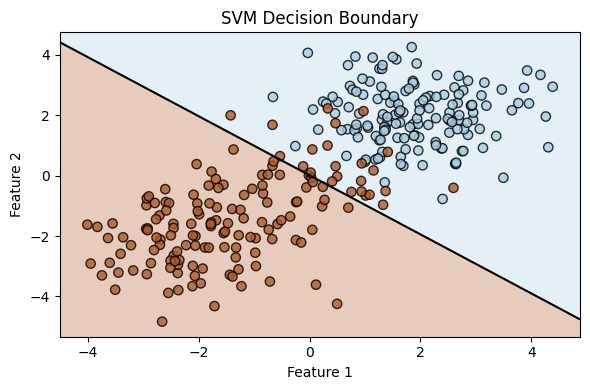

In [35]:
plt.figure(figsize=(6, 4))

# Initialize grid step size and axis bounds
h = 0.02
feat1_min, feat1_max = features[:, 0].min() - 0.5, features[:, 0].max() + 0.5
feat2_min, feat2_max = features[:, 1].min() - 0.5, features[:, 1].max() + 0.5

# Create a 2D grid covering the feature space
feat1_grid, feat2_grid = np.meshgrid(
    np.arange(feat1_min, feat1_max, h),
    np.arange(feat2_min, feat2_max, h),
)

# Compute the raw decision function value for every grid point
grid_points = np.c_[feat1_grid.ravel(), feat2_grid.ravel()]
scores = (np.dot(grid_points, svm.weights) + svm.bias).reshape(feat1_grid.shape)

# Fill the class regions
region = (scores >= 0).astype(int)
plt.contourf(feat1_grid, feat2_grid, region, cmap="Paired", alpha=0.3)

# Plot the decision boundary
plt.contour(feat1_grid, feat2_grid, scores, levels=[0], colors="k", linewidths=1.5)

plt.scatter(
    features[:, 0],
    features[:, 1],
    c=(transformed_labels == 1).astype(int),
    cmap="Paired",
    edgecolors="k",
    s=45,
    alpha=0.8,
)
plt.title("SVM Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()